## Aravind's Contribution

## Tuning and updating values for better Image Generation for VAE

- Deep encoder-decoder (DCGAN-like)
- β-VAE KL tuning (beta=1.0) for better disentanglement
- MSE reconstruction loss (sharper than BCE for image generation)
- Image normalization from [-1, 1] for Tanh

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.utils import save_image, make_grid
from tqdm import tqdm
import os

## Updated Configuration

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 128
batch_size = 128
epochs = 30
lr = 2e-4
image_size = 64
beta = 1.0  # KL loss weight

- latent_dim # Increased latent space for better feature encoding
- batch_size # Larger batches improve gradient estimates
- epochs # Longer training improves convergence
- lr # Slightly higher LR for faster learning
- image_size # Higher resolution for better detail
- beta # β-VAE: balances reconstruction vs disentanglement
## - *Old VAE: Smaller latent dim, default β=1 → poor generalization and blurry images*
## - *Change: Added beta for control, increased latent_dim to enhance feature richness*

## Updated Transforms

In [29]:
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)  # for Tanh
])

## - *Old VAE: Likely used [0,1] normalization for BCE loss*
## - *Change: Normalized to [-1,1] for better training with Tanh and MSE loss*

## DATASET 

In [30]:
dataset = datasets.ImageFolder(root="balanced_labeled_photos", transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)

## VAE Model with updated metrics

In [31]:
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),  # -> 32x32
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),  # -> 16x16
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1),  # -> 8x8
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 512, 4, 2, 1),  # -> 4x4
            nn.BatchNorm2d(512), nn.ReLU()
        )
        self.fc_mu = nn.Linear(512 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(512 * 4 * 4, latent_dim)

    def forward(self, x):
        x = self.conv(x).view(x.size(0), -1)
        return self.fc_mu(x), self.fc_logvar(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 512 * 4 * 4)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, z):
        z = self.fc(z).view(z.size(0), 512, 4, 4)
        return self.deconv(z)

class VAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

## - *Deep CNN layers for better visual features*
## - *Old VAE: Used fully connected encoder or shallow CNN*
## - *Change: Deeper CNN structure captures spatial info better → sharper output*
## - *Old VAE: Used Sigmoid and shallow decoder*
## - *Change: Tanh + deep upsampling improves output diversity + sharper edges*

## Updated Loss Function

In [32]:
def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')  # sharper than BCE
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl_div

## - *Old VAE: Used BCE loss (causes blurriness)*
## - *Change: Switched to MSE for sharper, more photorealistic generations*

## Train

In [33]:
vae = VAE(latent_dim).to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=lr)
os.makedirs("vae_outputs", exist_ok=True)

for epoch in range(epochs):
    vae.train()
    total_loss = 0
    loop = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")

    for imgs, _ in loop:
        imgs = imgs.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = vae(imgs)
        loss = vae_loss(recon, imgs, mu, logvar, beta)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        loop.set_postfix(loss=loss.item() / len(imgs))

    print(f"Epoch {epoch+1}: Avg Loss = {total_loss / len(dataloader.dataset):.2f}")

Epoch 1/30: 100%|██████████████████████████████████████████████████████| 737/737 [02:02<00:00,  6.02it/s, loss=1.01e+3]


Epoch 1: Avg Loss = 1389.43


Epoch 2/30: 100%|██████████████████████████████████████████████████████████| 737/737 [02:07<00:00,  5.78it/s, loss=939]


Epoch 2: Avg Loss = 920.14


Epoch 3/30: 100%|██████████████████████████████████████████████████████████| 737/737 [02:03<00:00,  5.98it/s, loss=828]


...

Epoch 28: Avg Loss = 730.55


Epoch 29/30: 100%|█████████████████████████████████████████████████████████| 737/737 [02:09<00:00,  5.68it/s, loss=691]


Epoch 29: Avg Loss = 729.34


Epoch 30/30: 100%|█████████████████████████████████████████████████████████| 737/737 [02:21<00:00,  5.23it/s, loss=796]

Epoch 30: Avg Loss = 729.02


## Save reconstructions

In [35]:
with torch.no_grad():
    recon = (recon + 1) / 2
    save_image(recon[:8], f"vae_outputs/recon_epoch{epoch+1}.png", nrow=4)

## Save 5 generated images

In [36]:
with torch.no_grad():
    z = torch.randn(5, latent_dim).to(device)
    gen_imgs = vae.decoder(z)
    gen_imgs = (gen_imgs + 1) / 2
    for i in range(5):
        save_image(gen_imgs[i], f"vae_outputs/vae_gen_upd{i+1}.png")

## Save Model with Updated Metrics

In [37]:
torch.save(vae.state_dict(), "vae_outputs/vae_model_upd.pth")

## Evaluation of IS, FID 

In [38]:
import os
import glob
import torch
from torchvision import transforms
from torchvision.utils import save_image
from PIL import Image
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore

## Load VAE Model

In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 128  
model = VAE(latent_dim=latent_dim).to(device)
model.load_state_dict(torch.load("vae_outputs/vae_model_upd.pth", map_location=device))
model.eval()

VAE(
  (encoder): Encoder(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): ReLU()
      (9): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (10): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (11): ReLU()
    )
    (fc_mu): Linear(in_features=8192, out_features=128, bias=True)
    (fc_logvar): Linear(in_features=8192, out_features=128, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_featur

## Generate 100 Fake Images

In [59]:
import torch
import os
from torchvision.utils import save_image

# Ensure this matches your architecture
class Encoder(torch.nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.conv = torch.nn.Sequential(
            torch.nn.Conv2d(3, 64, 4, 2, 1),
            torch.nn.BatchNorm2d(64), torch.nn.ReLU(),
            torch.nn.Conv2d(64, 128, 4, 2, 1),
            torch.nn.BatchNorm2d(128), torch.nn.ReLU(),
            torch.nn.Conv2d(128, 256, 4, 2, 1),
            torch.nn.BatchNorm2d(256), torch.nn.ReLU(),
            torch.nn.Conv2d(256, 512, 4, 2, 1),
            torch.nn.BatchNorm2d(512), torch.nn.ReLU()
        )
        self.fc_mu = torch.nn.Linear(512 * 4 * 4, latent_dim)
        self.fc_logvar = torch.nn.Linear(512 * 4 * 4, latent_dim)

    def forward(self, x):
        x = self.conv(x).view(x.size(0), -1)
        return self.fc_mu(x), self.fc_logvar(x)

class Decoder(torch.nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = torch.nn.Linear(latent_dim, 512 * 4 * 4)
        self.deconv = torch.nn.Sequential(
            torch.nn.ConvTranspose2d(512, 256, 4, 2, 1),
            torch.nn.BatchNorm2d(256), torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(256, 128, 4, 2, 1),
            torch.nn.BatchNorm2d(128), torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(128, 64, 4, 2, 1),
            torch.nn.BatchNorm2d(64), torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(64, 3, 4, 2, 1),
            torch.nn.Tanh()
        )

    def forward(self, z):
        z = self.fc(z).view(z.size(0), 512, 4, 4)
        return self.deconv(z)

class VAE(torch.nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 128

# Load model
model = VAE(latent_dim=latent_dim).to(device)
model.load_state_dict(torch.load("vae_outputs/vae_model_upd.pth", map_location=device))
model.eval()

# Generate and save images
os.makedirs("vae_outputs/generated_fake", exist_ok=True)

with torch.no_grad():
    for i in range(100):
        z = torch.randn(1, latent_dim).to(device)
        generated = model.decoder(z).cpu()
        generated = (generated + 1) / 2  # Convert from [-1, 1] to [0, 1]
        save_image(generated, f"vae_outputs/generated_fake/vae_gen_{i}.png")

## Inception Score & FID

## Resize to 299×299 for Inception model

In [86]:
transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),  # returns [0,1] float32
])

In [87]:
def load_images_uint8(folder_path, transform, max_images=None):
    images = []
    for fname in sorted(os.listdir(folder_path)):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(folder_path, fname)
            img = Image.open(img_path).convert("RGB")
            img = transform(img)           # [0, 1]
            img = (img * 255).byte()       # convert to uint8 [0,255]
            images.append(img)
            if max_images and len(images) >= max_images:
                break
    if not images:
        raise ValueError(f"No valid images found in {folder_path}")
    return torch.stack(images)

## Paths

In [88]:
real_path = r"C:\Users\User\Desktop\CV\assignment_ver2\casestudy2\balanced_labeled_photos\food"
fake_path = r"C:\Users\User\Desktop\CV\assignment_ver2\casestudy2\vae_outputs\generated_fake"

## Load Both Images (Limit to 100)

In [90]:
real_images = load_images_uint8(real_path, transform, max_images=100).to(device)
fake_images = load_images_uint8(fake_path, transform, max_images=100).to(device)

In [91]:
print("Images loaded:", real_images.shape, fake_images.shape)

Images loaded: torch.Size([100, 3, 299, 299]) torch.Size([100, 3, 299, 299])


## Inception Score

In [92]:
is_metric = InceptionScore().to(device)
is_metric.update(fake_images)
inception_score = is_metric.compute()
print(f"Inception Score: {inception_score[0]:.3f} ± {inception_score[1]:.3f}")

Inception Score: 1.978 ± 0.248


## Frechet Inception Distance (FID) Score

In [93]:
fid_metric = FrechetInceptionDistance(feature=2048).to(device)
fid_metric.update(real_images, real=True)
fid_metric.update(fake_images, real=False)
fid_score = fid_metric.compute()
print(f"FID Score: {fid_score.item():.2f}")

FID Score: 339.09


## Display 5 Generated Images

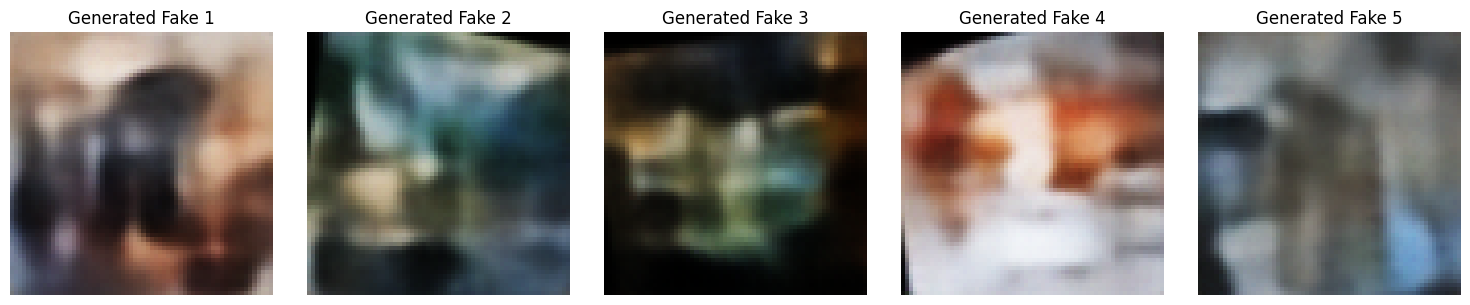

In [95]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

folder_path = "vae_outputs/generated_fake"

# Transformation for display
transform = transforms.Compose([
    transforms.Resize((64, 64)), 
    transforms.ToTensor()
])

# Load and display 5 images
def show_generated_images(folder, num_images=5):
    image_files = sorted([
        f for f in os.listdir(folder) if f.endswith('.png') or f.endswith('.jpg')
    ])[:num_images]
    
    plt.figure(figsize=(15, 3))
    for idx, image_file in enumerate(image_files):
        img_path = os.path.join(folder, image_file)
        image = Image.open(img_path)
        tensor_img = transform(image)
        np_img = tensor_img.permute(1, 2, 0).numpy()

        plt.subplot(1, num_images, idx + 1)
        plt.imshow(np_img)
        plt.title(f"Generated Fake {idx+1}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Call the function
show_generated_images("vae_outputs/generated_fake")

## Both the Model's Comparison

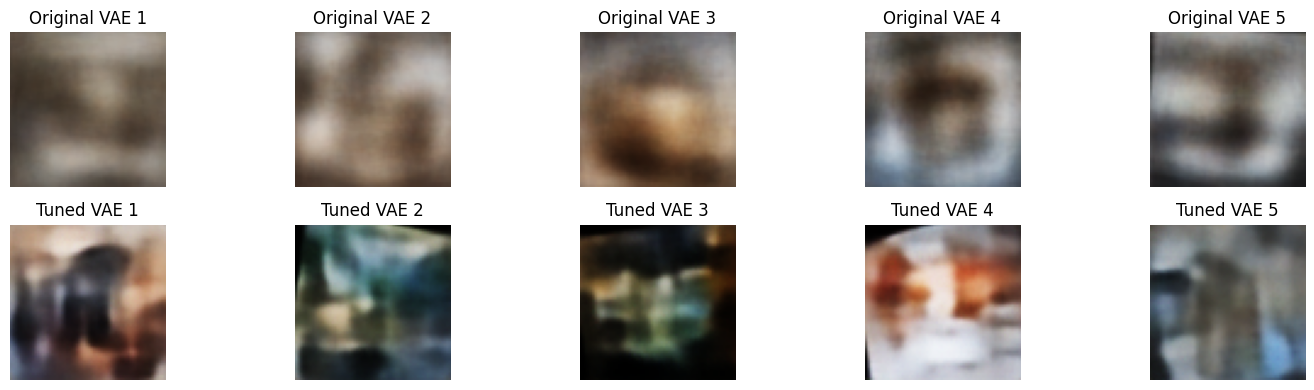

In [96]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
import torch

# Transformation to match model output
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# Load images from a folder
def load_generated_images(folder_path, num_images=5):
    image_files = sorted([
        f for f in os.listdir(folder_path) if f.endswith('.png') or f.endswith('.jpg')
    ])[:num_images]
    
    images = []
    for filename in image_files:
        path = os.path.join(folder_path, filename)
        image = Image.open(path).convert('RGB')
        images.append(transform(image))
    return images

# Folders for the original and improved VAE
original_vae_path = "vae_outputs/generated"  
tuned_vae_path = "vae_outputs/generated_fake"    

# Load images
original_images = load_generated_images(original_vae_path)
tuned_images = load_generated_images(tuned_vae_path)

# Comparison plot
def plot_vae_comparison(original_imgs, tuned_imgs):
    n = min(len(original_imgs), len(tuned_imgs))
    plt.figure(figsize=(15, 4))
    for i in range(n):
        # Original VAE image
        plt.subplot(2, n, i + 1)
        plt.imshow(original_imgs[i].permute(1, 2, 0))
        plt.title(f"Original VAE {i+1}")
        plt.axis('off')
        
        # Tuned VAE image
        plt.subplot(2, n, n + i + 1)
        plt.imshow(tuned_imgs[i].permute(1, 2, 0))
        plt.title(f"Tuned VAE {i+1}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Run the plot
plot_vae_comparison(original_images, tuned_images)

### VAE Performance Comparison: Original vs Tuned

| Metric                         | Original VAE         | Tuned VAE           | Change                |
|-------------------------------|----------------------|---------------------|-----------------------|
| **Inception Score (IS)**      | 1.674 ± 0.193        | 1.978 ± 0.248       |  +0.304 (improved)  |
| **Frechet Inception Distance (FID)** | 366.98               | 339.09              |  -27.89 (better)    |

---

### Summary

- **Inception Score (IS)** increased, indicating **greater diversity and clarity** in generated images.
- **FID Score** decreased, reflecting **better visual similarity** to real images and more realistic outputs.

| Feature                 | Old VAE        |  Improved VAE                              |
|------------------------|----------------|----------------------------------------------------|
| **Encoder/Decoder Depth**  | Shallow        | DCGAN-style deep encoder/decoder (5 layers each)   |
| **Latent Space Size**      | Small (~32)    | Larger (`latent_dim = 128`) for better feature richness |
| **Reconstruction Loss**    | BCE            | **MSE** – sharper output, less blurry              |
| **Normalization**          | [0,1]          | **[-1,1]** with `Tanh` activation in decoder        |
| **Beta-VAE Tuning**        | No             |  Enabled (β = 1.0) for KL loss scaling            |
| **No of Epoch's**        | 10             |  30            |
| **Total Training Time**        | 15 minutes             |  45 minutes            |

## LLM Prompts
- First: What are parameters to tune VAE Model
- Last: How to plot comparision for both the models